In [1]:
# ============================================================
# NOTEBOOK 02: MODEL TRAINING & EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import time

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# ------------------------------------------------------------
# STEP 1: Load Processed Data
# ------------------------------------------------------------
# Load from disk (clean separation from preprocessing)
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Loaded: X_train {X_train.shape}, X_test {X_test.shape}")

Loaded: X_train (648360, 25), X_test (196032, 25)


In [3]:
# ------------------------------------------------------------
# STEP 2: Create Sample for Fast Experimentation
# ------------------------------------------------------------
# Full dataset is large (~800K rows) - sample for quick iteration
# Final models can train on full data later

SAMPLE_SIZE = 100000  # Adjust based on your computer's speed

X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

X_test_sample = X_test.sample(n=50000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

print(f"Sampled: X_train {X_train_sample.shape}, X_test {X_test_sample.shape}")

Sampled: X_train (100000, 25), X_test (50000, 25)


In [4]:
# ------------------------------------------------------------
# STEP 3: Evaluation Function
# ------------------------------------------------------------
def evaluate_model(y_true, y_pred, model_name, sample_size=50000):
    """
    Calculates RMSE and MAE with optional sampling for speed.
    
    RMSE: Root Mean Squared Error (penalizes large errors)
    MAE: Mean Absolute Error (average absolute error)
    """
    # Convert to numpy for faster computation
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Subsample if data is huge (speed optimization)
    if len(y_true) > sample_size:
        idx = np.random.choice(len(y_true), sample_size, replace=False)
        y_true = y_true[idx]
        y_pred = y_pred[idx]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f"{model_name} Performance")
    print(f"{'='*40}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"{'='*40}")
    
    return rmse, mae

In [5]:
# ------------------------------------------------------------
# STEP 4: Baseline Model - Linear Regression
# ------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING LINEAR REGRESSION (Baseline)")
print("="*50)

start_time = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predict
y_pred_lr = lr_model.predict(X_test_sample)

# Evaluate
rmse_lr, mae_lr = evaluate_model(y_test_sample, y_pred_lr, "Linear Regression")


TRAINING LINEAR REGRESSION (Baseline)
Training time: 0.38 seconds

Linear Regression Performance
RMSE: 2,678.76
MAE:  2,001.17


In [6]:
# ------------------------------------------------------------
# STEP 5: Random Forest (Optimized for Speed)
# ------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING RANDOM FOREST")
print("="*50)

start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=50,      # Number of trees (reduced for speed)
    max_depth=8,          # Limit depth to prevent overfitting
    min_samples_split=100, # Minimum samples to split a node
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predict
y_pred_rf = rf_model.predict(X_test_sample)

# Evaluate
rmse_rf, mae_rf = evaluate_model(y_test_sample, y_pred_rf, "Random Forest")


TRAINING RANDOM FOREST
Training time: 13.58 seconds

Random Forest Performance
RMSE: 2,436.06
MAE:  1,774.40


In [7]:
# ------------------------------------------------------------
# STEP 6: XGBoost (Industry Standard)
# ------------------------------------------------------------
print("\n" + "="*50)
print("TRAINING XGBOOST")
print("="*50)

start_time = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=100,      # Boosting rounds
    learning_rate=0.1,     # Step size shrinkage
    max_depth=6,           # Tree depth
    subsample=0.8,         # Row sampling ratio
    colsample_bytree=0.8,  # Feature sampling ratio
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predict
y_pred_xgb = xgb_model.predict(X_test_sample)

# Evaluate
rmse_xgb, mae_xgb = evaluate_model(y_test_sample, y_pred_xgb, "XGBoost")


TRAINING XGBOOST
Training time: 2.76 seconds

XGBoost Performance
RMSE: 1,790.43
MAE:  1,312.11


In [8]:
# ------------------------------------------------------------
# STEP 7: Model Comparison
# ------------------------------------------------------------
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_xgb]
}).sort_values('RMSE')

print("\n" + "="*50)
print("MODEL COMPARISON (Ranked by RMSE)")
print("="*50)
print(results.to_string(index=False))


MODEL COMPARISON (Ranked by RMSE)
            Model        RMSE         MAE
          XGBoost 1790.427253 1312.107178
    Random Forest 2436.056882 1774.398305
Linear Regression 2678.764385 2001.172561


In [9]:
# ------------------------------------------------------------
# STEP 8: Feature Importance (Business Insights)
# ------------------------------------------------------------
print("\n" + "="*50)
print("TOP 10 FEATURES (Random Forest)")
print("="*50)

importance_df = pd.DataFrame({
    'Feature': X_train_sample.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))


TOP 10 FEATURES (Random Forest)
            Feature  Importance
              Promo    0.210355
            IsPromo    0.140877
CompetitionDistance    0.129110
          DayOfWeek    0.081071
              Store    0.070544
    Promo2SinceYear    0.068981
         WeekOfYear    0.062283
        StoreType_b    0.056672
       Assortment_c    0.052262
                Day    0.029852


In [10]:
# ------------------------------------------------------------
# STEP 9: Save Best Model
# ------------------------------------------------------------
import joblib

# Determine best model
best_model_name = results.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")

# Save XGBoost (usually best) - adjust if RF wins
joblib.dump(xgb_model, '../models/model.pkl')
print("✅ Model saved to ../models/model.pkl")


Best model: XGBoost
✅ Model saved to ../models/model.pkl



GENERATING SHAP EXPLANATIONS


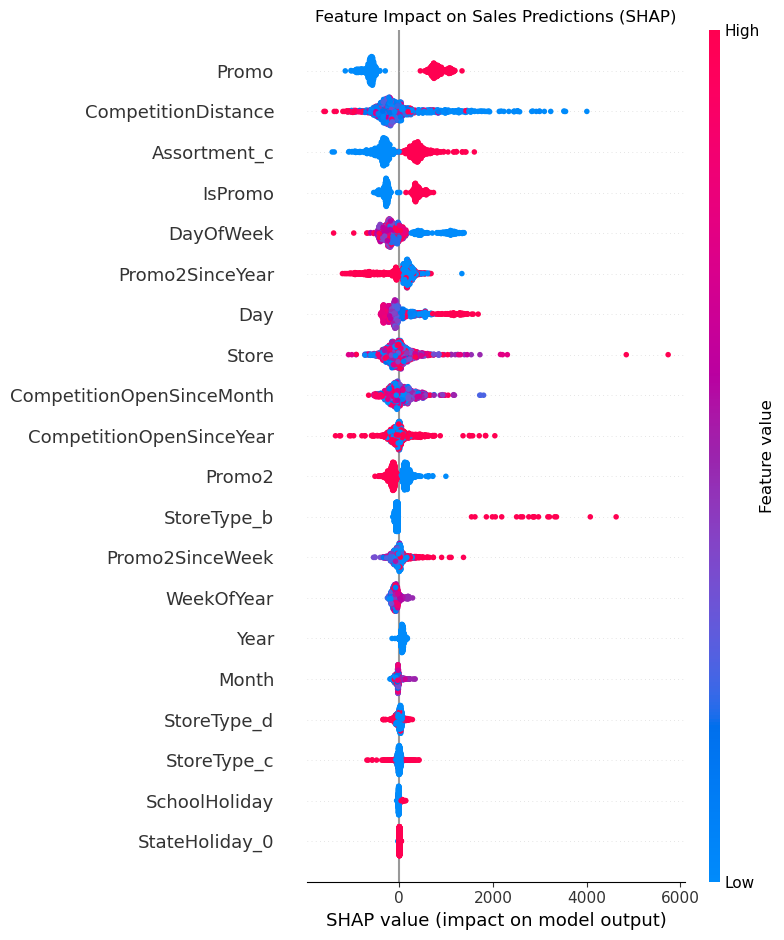

✅ SHAP analysis complete - check business insights below


In [12]:
# ------------------------------------------------------------
# SHAP EXPLAINABILITY (Add after model training)
# ------------------------------------------------------------
import shap
import matplotlib.pyplot as plt  # ← ADD THIS LINE

print("\n" + "="*50)
print("GENERATING SHAP EXPLANATIONS")
print("="*50)

# Create explainer for tree-based model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for sample (first 1000 rows for speed)
shap_values = explainer.shap_values(X_test_sample.iloc[:1000])

# Summary plot - shows which features drive predictions
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample.iloc[:1000], show=False)
plt.title("Feature Impact on Sales Predictions (SHAP)")
plt.tight_layout()
plt.savefig('../models/shap_summary.png')  # Save for README
plt.show()

print("✅ SHAP analysis complete - check business insights below")

In [13]:
# ============================================================
# CELL: SAVE MODEL FOR DEPLOYMENT
# ============================================================

import joblib

# Save the trained XGBoost model
model_path = '../models/xgboost_sales_model.pkl'
joblib.dump(xgb_model, model_path)

print(f"✅ Model saved: {model_path}")
print(f"Model size: {joblib.load(model_path).__sizeof__() / 1024 / 1024:.2f} MB")

✅ Model saved: ../models/xgboost_sales_model.pkl
Model size: 0.00 MB


In [14]:
import os
import joblib

# Check actual file size on disk
model_path = '../models/xgboost_sales_model.pkl'
file_size = os.path.getsize(model_path) / 1024 / 1024  # MB

print(f"✅ Model file exists: {os.path.exists(model_path)}")
print(f"📁 Actual file size: {file_size:.2f} MB")
print(f"📅 Last modified: {os.path.getmtime(model_path)}")

# Test loading and prediction
loaded_model = joblib.load(model_path)
sample_pred = loaded_model.predict(X_test_sample.iloc[:5])
print(f"\n🎯 Test prediction (5 samples): {sample_pred}")

✅ Model file exists: True
📁 Actual file size: 0.46 MB
📅 Last modified: 1775412257.241973

🎯 Test prediction (5 samples): [6358.2754 4595.552  6262.636  5952.6206 4406.567 ]
